In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from IPython.core.interactiveshell import InteractiveShell
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all" 

In [120]:
# 加载数据
train = pd.read_csv("train_new_features.csv")
test = pd.read_csv("test_new_features.csv")

y=train['Transported'].copy().astype(int)
X=train.drop('Transported', axis=1).copy()

# 合并测试集和训练集
data=pd.concat([X, test], axis=0).reset_index(drop=True)

# 缺失值分析

In [121]:
# 缺失值数量
print("\n缺失值数量")
print(data.isnull().sum())

# # 生成缺失值指示矩阵（1=缺失，0=存在）
# missing_indicator = data.isnull().astype(int)

# # 计算缺失值之间的相关性
# missing_corr = missing_indicator.corr()

# # 绘制热力图
# plt.figure(figsize=(15, 8))
# sns.heatmap(missing_corr, annot=True, cmap='coolwarm', fmt=".2f", 
#             mask=np.triu(np.ones_like(missing_corr, dtype=bool)))
# plt.title("Correlation Between Missing Values", fontsize=12)
# plt.show()


缺失值数量
Unnamed: 0        0
PassengerId       0
HomePlanet      288
CryoSleep       310
Destination     274
Age             270
VIP             296
RoomService     263
FoodCourt       289
ShoppingMall    306
Spa             284
VRDeck          268
Name            294
exp_tol           0
No_spending       0
Group             0
Group_size        0
Solo              0
Cabin_deck      299
Cabin_number    299
Cabin_side      299
Surname         294
Family_Size     294
dtype: int64


发现缺失值相关性很弱

In [122]:
initial_count = len(data)
data_dropped = data.dropna()
remaining_ratio = len(data_dropped) / initial_count
print(f"移除所有缺失行后剩余数据比例: {remaining_ratio:.2%}")

移除所有缺失行后剩余数据比例: 76.23%


剩余数据量太少，不能删

## 缺失值处理


## 一、HomePlanet缺失值处理

### 2.同一组的人来自同一颗星球

HomePlanet,Earth,Europa,Mars
Group,,,
1,0.0,1.0,0.0
2,1.0,0.0,0.0
3,0.0,2.0,0.0
4,1.0,0.0,0.0
5,1.0,0.0,0.0


<Figure size 1000x400 with 0 Axes>

<Axes: xlabel='HomePlanet', ylabel='count'>

Text(0.5, 1.0, 'Number of unique planets per surname')

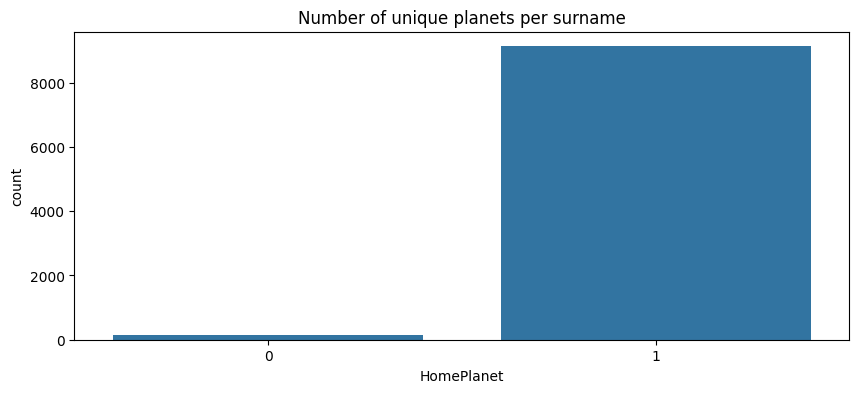

In [123]:
GHP_gb=data.groupby(['Group','HomePlanet'])['HomePlanet'].size().unstack().fillna(0)
GHP_gb.head()



planet_counts = data.groupby('Group')['HomePlanet'].nunique()
plt.figure(figsize=(10,4))
sns.countplot(x=planet_counts,data=data)
plt.title('Number of unique planets per surname')


只有1和0两类，说明同一组的乘客都来自同一星球。（0代表该组乘客的家乡星球字段都为空）

In [124]:
#填充缺失值

HP_bef=data['HomePlanet'].isna().sum()

# Passengers with missing HomePlanet and in a group with known HomePlanet
GHP_index=data[data['HomePlanet'].isna()][(data[data['HomePlanet'].isna()]['Group']).isin(GHP_gb.index)].index

# Fill corresponding missing values
data.loc[GHP_index,'HomePlanet']=data.iloc[GHP_index,:]['Group'].map(lambda x: GHP_gb.idxmax(axis=1)[x])

# Print number of missing values left
print('#HomePlanet missing values before:',HP_bef)
print('#HomePlanet missing values after:',data['HomePlanet'].isna().sum())





#HomePlanet missing values before: 288
#HomePlanet missing values after: 157


### 3. 家乡星球与甲板

HomePlanet,Earth,Europa,Mars
Cabin_deck,,,
A,0.0,352.0,0.0
B,0.0,1137.0,0.0
C,0.0,1096.0,0.0
D,0.0,301.0,410.0
E,589.0,199.0,515.0


<Figure size 1000x400 with 0 Axes>

<Axes: xlabel='HomePlanet', ylabel='Cabin_deck'>

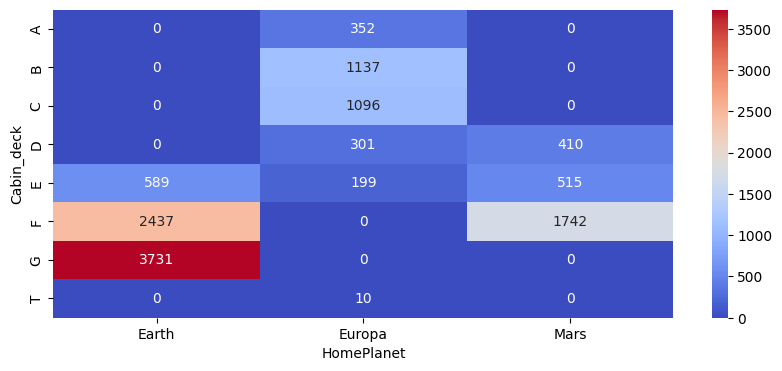

In [125]:
# Joint distribution of CabinDeck and HomePlanet
CDHP_gb=data.groupby(['Cabin_deck','HomePlanet'])['HomePlanet'].size().unstack().fillna(0)
CDHP_gb.head()

# 查看关系
plt.figure(figsize=(10,4))
sns.heatmap(CDHP_gb, annot=True, fmt='g', cmap='coolwarm')

可以看到：
A,B,C,G,T层的乘客都来自欧罗巴
D层的乘客来自火星和来自欧罗巴的各占一半
E层来自各地都有
F层有乘客来自欧罗巴和火星



In [126]:
# Missing values before
HP_bef=data['HomePlanet'].isna().sum()

# Decks A, B, C or T came from Europa
data.loc[(data['HomePlanet'].isna()) & (data['Cabin_deck'].isin(['A', 'B', 'C', 'T'])), 'HomePlanet']='Europa'

# Deck G came from Earth
data.loc[(data['HomePlanet'].isna()) & (data['Cabin_deck']=='G'), 'HomePlanet']='Earth'

# Print number of missing values left
print('#HomePlanet missing values before:',HP_bef)
print('#HomePlanet missing values after:',data['HomePlanet'].isna().sum())

#HomePlanet missing values before: 157
#HomePlanet missing values after: 94


### 4. 家乡星球和家族名

HomePlanet,Earth,Europa,Mars
Surname,,,
Acobson,5.0,0.0,0.0
Acobsond,8.0,0.0,0.0
Adavisons,10.0,0.0,0.0
Adkinson,4.0,0.0,0.0
Admingried,0.0,4.0,0.0


Surname
Acobson       1
Acobsond      1
Adavisons     1
Adkinson      1
Admingried    1
Name: HomePlanet, dtype: int64

<Figure size 1000x400 with 0 Axes>

<Axes: xlabel='HomePlanet', ylabel='count'>

Text(0.5, 1.0, 'Number of unique planets per surname')

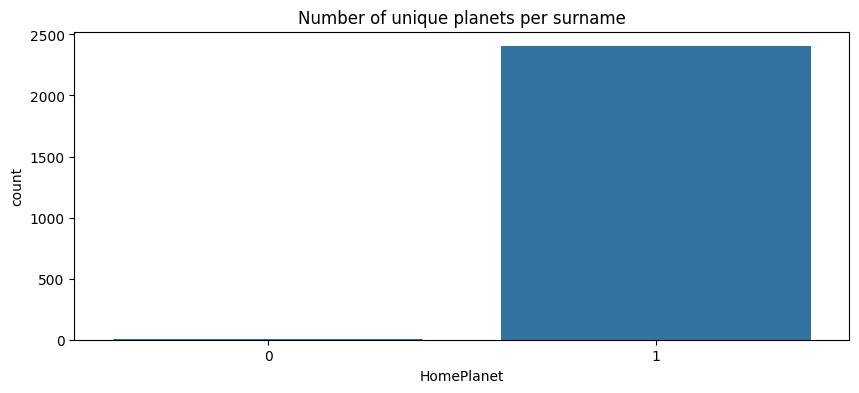

In [127]:
# 粗略观察下二者关系
SHP_gb = data.groupby(['Surname','HomePlanet'])['HomePlanet'].size().unstack().fillna(0)
SHP_gb.head()
# 统计每个姓氏中成员来自多少个的星球
planet_counts = data.groupby('Surname')['HomePlanet'].nunique()

planet_counts.head()
# Countplot of unique values
plt.figure(figsize=(10,4))
sns.countplot(x=planet_counts,data=data)
plt.title('Number of unique planets per surname')

可以看到只有1和0两类。这说明同一姓氏的乘客都来自同一星球。（0代表该姓氏的乘客的家乡星球字段都缺失了）

In [128]:
# Missing values before
HP_bef=data['HomePlanet'].isna().sum()

# Passengers with missing HomePlanet and in a family with known HomePlanet
SHP_index=data[data['HomePlanet'].isna()][(data[data['HomePlanet'].isna()]['Surname']).isin(SHP_gb.index)].index

# Fill corresponding missing values
data.loc[SHP_index,'HomePlanet'] = data.iloc[SHP_index,:]['Surname'].map(lambda x: SHP_gb.idxmax(axis=1)[x])

# Print number of missing values left
print('#HomePlanet missing values before:',HP_bef)
print('#HomePlanet missing values after:',data['HomePlanet'].isna().sum())

#HomePlanet missing values before: 94
#HomePlanet missing values after: 10


### 5.家乡星球与目的星球

<Figure size 1000x400 with 0 Axes>

<Axes: xlabel='HomePlanet', ylabel='Destination'>

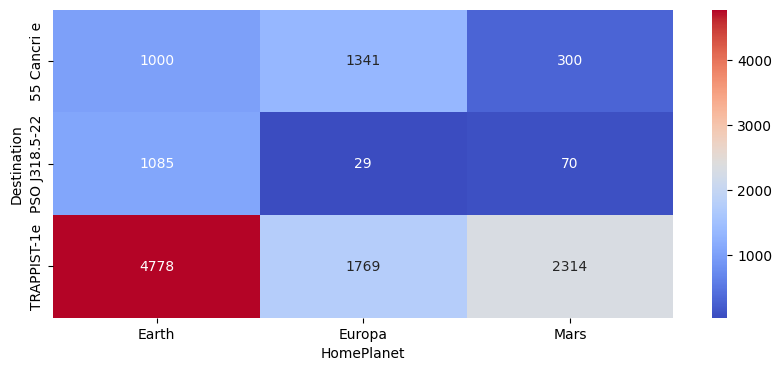

In [129]:
# 这两字段的联合分布
HPD_gb=data.groupby(['HomePlanet','Destination'])['Destination'].size().unstack().fillna(0)

# Heatmap of missing values
plt.figure(figsize=(10,4))
sns.heatmap(HPD_gb.T, annot=True, fmt='g', cmap='coolwarm')

可以见得，大多数人都是去TRAPPIST-1e的。
结合上面对Cabin和家乡星球的分析，我们取众数填充缺失值。

In [130]:
# Missing values before
HP_bef=data['HomePlanet'].isna().sum()

# 非D层甲板的乘客大多来自地球
data.loc[(data['HomePlanet'].isna()) & ~(data['Cabin_deck']=='D'), 'HomePlanet']='Earth'
#D层甲板乘客大多来自火星
data.loc[(data['HomePlanet'].isna()) & (data['Cabin_deck']=='D'), 'HomePlanet']='Mars'

# Print number of missing values left
print('#HomePlanet missing values before:',HP_bef)
print('#HomePlanet missing values after:',data['HomePlanet'].isna().sum())

#HomePlanet missing values before: 10
#HomePlanet missing values after: 0


至此，HomePlanet缺失值处理完毕。

## 二、目的字段缺失值处理

先看看有多少缺失值

In [131]:
data['Destination'].isna().sum()

274

<Figure size 1000x400 with 0 Axes>

<Axes: xlabel='Cabin_deck', ylabel='Destination'>

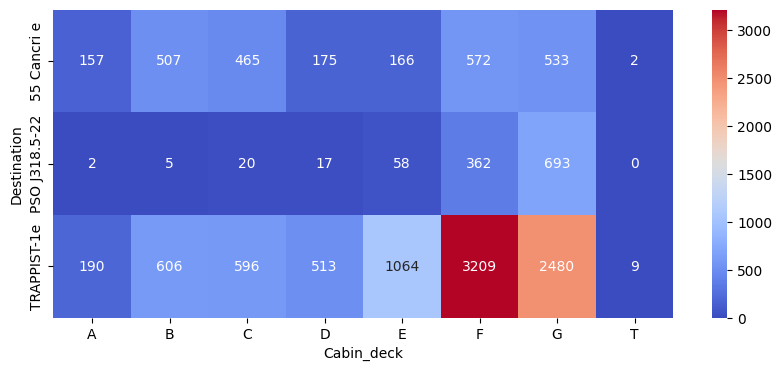

In [132]:
CDD_gb=data.groupby(['Cabin_deck','Destination'])['Destination'].size().unstack().fillna(0)

# Heatmap of missing values
plt.figure(figsize=(10,4))
sns.heatmap(CDD_gb.T, annot=True, fmt='g', cmap='coolwarm')

经过比较，还是根据上面家乡星球和目的地的关系来填充缺失值。

In [133]:
# Missing values before
D_bef=data['Destination'].isna().sum()

# Fill missing Destination values with mode
data.loc[(data['Destination'].isna()), 'Destination']='TRAPPIST-1e'

# Print number of missing values left
print('#Destination missing values before:',D_bef)
print('#Destination missing values after:',data['Destination'].isna().sum())

#Destination missing values before: 274
#Destination missing values after: 0


## 三、姓氏缺失值处理

Surname,Acobson,Acobsond,Adavisons,Admingried,Aginge,Ailled,Aillyber,Ainatint,Aindlylid,Ainserfle,...,Woody,Wooes,Wooterston,Workmans,Workmanson,Wriggins,Yanton,Yatters,Yorkland,Youngrayes
Group,,,,,,,,,,,,,,,,,,,,,
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
17,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


<Figure size 1000x400 with 0 Axes>

<Axes: xlabel='Surname', ylabel='count'>

Text(0.5, 1.0, 'Number of unique surnames by group')

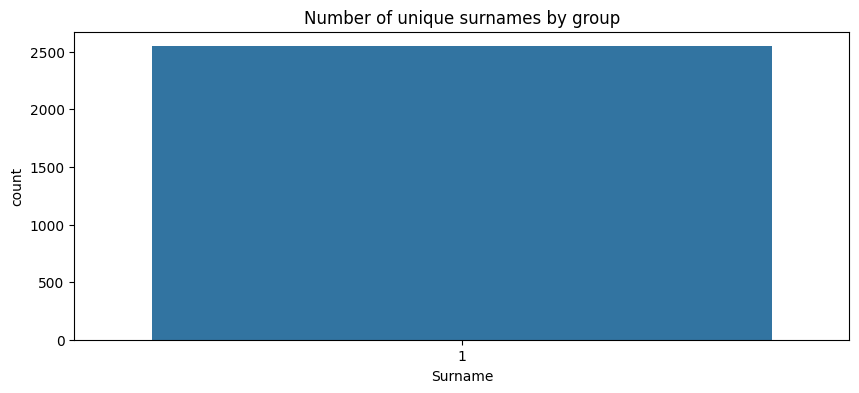

In [134]:
GSN_gb=data[data['Group_size']>1].groupby(['Group','Surname'])['Surname'].size().unstack().fillna(0)
GSN_gb.head()
surnames = data[data['Group_size']>1].groupby(['Group','Surname'])['Surname'].nunique()

# Countplot of unique values
plt.figure(figsize=(10,4))
sns.countplot(x = surnames,data=data)
plt.title('Number of unique surnames by group')

每个组的成员的姓氏都一样，这里和guide的结果不一样。但要进行的操作是一样。

In [135]:
# Missing values before
SN_bef=data['Surname'].isna().sum()

# Passengers with missing Surname and in a group with known majority Surname
GSN_index=data[data['Surname'].isna()][(data[data['Surname'].isna()]['Group']).isin(GSN_gb.index)].index

# Fill corresponding missing values
data.loc[GSN_index,'Surname']=data.iloc[GSN_index,:]['Group'].map(lambda x: GSN_gb.idxmax(axis=1)[x])

# Print number of missing values left
print('#Surname missing values before:',SN_bef)
print('#Surname missing values after:',data['Surname'].isna().sum())

#Surname missing values before: 294
#Surname missing values after: 155


删除或填充unknown

## 四、花费缺失值处理

In [136]:
#查看冬眠与花费的关系
data.groupby(['No_spending','CryoSleep'])['CryoSleep'].size().unstack().fillna(0)


CryoSleep,False,True
No_spending,,
0,7339.0,0.0
1,740.0,4581.0


In [137]:
exp_feats=['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
E_bef=data[exp_feats].isna().sum().sum()

for col in exp_feats:
    data.loc[(data[col].isna()) & (data['CryoSleep']==True), col]=0

print('#Expenditure missing values before:',E_bef)
print('#Expenditure missing values after:',data[exp_feats].isna().sum().sum())

#Expenditure missing values before: 1410
#Expenditure missing values after: 879


对冬眠字段缺失的记录，如果它的总消费为0，则认为该乘客冬眠。

In [138]:
# Missing values before
CSL_bef=data['CryoSleep'].isna().sum()

# Fill missing values using the mode


data.loc[data['CryoSleep'].isna() & data['No_spending']==0,'CryoSleep']  = True
data.loc[data['CryoSleep'].isna() & data['No_spending']==1,'CryoSleep']  = False

# Print number of missing values left
print('#CryoSleep missing values before:',CSL_bef)
print('#CryoSleep missing values after:',data['CryoSleep'].isna().sum())

#CryoSleep missing values before: 310
#CryoSleep missing values after: 0


## 五、舱室缺失值处理

同一组的人所在舱室应该都一样。

In [ ]:
a=data.groupby(['Group','Cabin_deck']).size()
a
a[a==0]

Group  Cabin_deck
1      B             1
2      F             1
3      A             2
4      F             1
5      F             1
                    ..
9276   A             1
9277   G             1
9278   G             1
9279   G             1
9280   E             2
Length: 9825, dtype: int64

<Axes: >

ValueError: If using all scalar values, you must pass an index

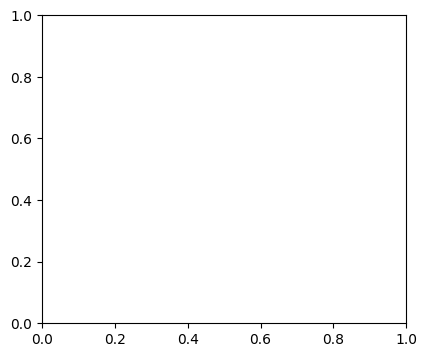

In [ ]:
# Joint distribution of Group and Cabin features
GCD_gb=data[data['Group_size']>1].groupby(['Group','Cabin_deck'])['Cabin_deck'].size().unstack().fillna(0)
GCN_gb=data[data['Group_size']>1].groupby(['Group','Cabin_number'])['Cabin_number'].size().unstack().fillna(0)
GCS_gb=data[data['Group_size']>1].groupby(['Group','Cabin_side'])['Cabin_side'].size().unstack().fillna(0)

CDs_per_group=data[data['Group_size']>1].groupby(['Group','Cabin_deck'])['Cabin_deck'].nunique()
CNs_per_group=data[data['Group_size']>1].groupby(['Group','Cabin_number'])['Cabin_number'].nunique()
CSs_per_group=data[data['Group_size']>1].groupby(['Group','Cabin_side'])['Cabin_side'].nunique()

# Countplots
fig=plt.figure(figsize=(16,4))
plt.subplot(1,3,1)
sns.countplot(x=CDs_per_group,data=data)
plt.title('#Unique cabin decks per group')

plt.subplot(1,3,2)
sns.countplot(x=CNs_per_group,data=data)
plt.title('#Unique cabin numbers per group')

plt.subplot(1,3,3)
sns.countplot(x=CSs_per_group,data=data)
plt.title('#Unique cabin sides per group')
fig.tight_layout()

In [ ]:
# Missing values before
CS_bef=data['Cabin_side'].isna().sum()
#填充缺失值
# Passengers with missing Cabin side and in a group with known Cabin side
GCS_index=data[data['Cabin_side'].isna()][(data[data['Cabin_side'].isna()]['Group']).isin(GCS_gb.index)].index

# Fill corresponding missing values
data.loc[GCS_index,'Cabin_side']=data.iloc[GCS_index,:]['Group'].map(lambda x: GCS_gb.idxmax(axis=1)[x])

# Print number of missing values left
print('#Cabin_side missing values before:',CS_bef)
print('#Cabin_side missing values after:',data['Cabin_side'].isna().sum())